In [1]:
from quantum import *
from random_functions import *
from matplotlib import color_sequences
from matplotlib import pyplot as plt
from tqdm import tqdm

In [2]:
rng = qml.numpy.random.default_rng(42)
device = qml.device('default.qubit', wires=N_QUBITS)

def mse_loss(circuit: qml.Qnode, theta: np.ndarray, collocation_points: np.ndarray, target: Callable) -> float:
    """
    Calculates the mean squared error between a parametrised circuit and a target function at a set of collocation points
    """
    return qml.numpy.mean((circuit(collocation_points, theta) - target(collocation_points))**2)

In [3]:
# n_collocation_points is the smallest round number greater than 2.5 times the maximum frequency (Nyquist-Shannon sampling theorem)
model_dict = {
    "Single Pauli Z": {
        "function": single_pauli_z_circuit,
        "n_collocation_points": 5,
    },
    "Triple Pauli Z": {
        "function": triple_pauli_z_circuit,
        "n_collocation_points": 10,
    },
    "Pauli Combination": {
        "function": optimal_pauli_combination_circuit,
        "n_collocation_points": 30,
    },
    "Optimal Spectrum": {
        "function": optimal_spectrum_diagonal_circuit,
        "n_collocation_points": 75,
    },
}

# number of random instances per target function
n_target_instances = 3

target_dict = {
    "Single Pauli Z": [generate_random_instance(single_pauli_z_circuit, device, rng) for _ in range(n_target_instances)],
    "Triple Pauli Z": [generate_random_instance(triple_pauli_z_circuit, device, rng) for _ in range(n_target_instances)],
    "Pauli Combination": [generate_random_instance(optimal_pauli_combination_circuit, device, rng) for _ in range(n_target_instances)],
    "Optimal Spectrum": [generate_random_instance(optimal_spectrum_diagonal_circuit, device, rng) for _ in range(n_target_instances)],
    "Random Series": [generate_random_fourier_series(1, rng), generate_random_fourier_series(3, rng), generate_random_fourier_series(10, rng)],
    "Polynomials": [generate_random_polynomial(1, rng), generate_random_polynomial(2, rng), generate_random_polynomial(3, rng)],
    "Exp Cos": [generate_exp_cos(3, 0.05), generate_exp_cos(8, 0.05), generate_exp_cos(20, 0.02)],
}
for key, val in target_dict.items():
    assert len(val) == n_target_instances, f"target_dict[{key}] has length {len(val)}, where it should have length {n_target_instances}"

#### Define the target and set up the plot

In [29]:
target_name = "Polynomials"
targets = target_dict[target_name]
file_name_plot = f"plots/Target: {target_name}.png"
file_name_table = f"tables/Target: {target_name}.csv"

n_steps = 1000
stepsize = 0.01

#### Do the fitting and plotting

Fitting model Single Pauli Z (1/4)
Fitting to target 1 out of 3


100%|██████████| 1000/1000 [00:14<00:00, 67.56it/s]


Fitting to target 2 out of 3


100%|██████████| 1000/1000 [00:13<00:00, 71.53it/s]


Fitting to target 3 out of 3


...

100%|██████████| 1000/1000 [00:26<00:00, 37.23it/s]


Fitting to target 2 out of 3


100%|██████████| 1000/1000 [00:34<00:00, 29.14it/s]


Fitting to target 3 out of 3


100%|██████████| 1000/1000 [00:35<00:00, 28.30it/s]


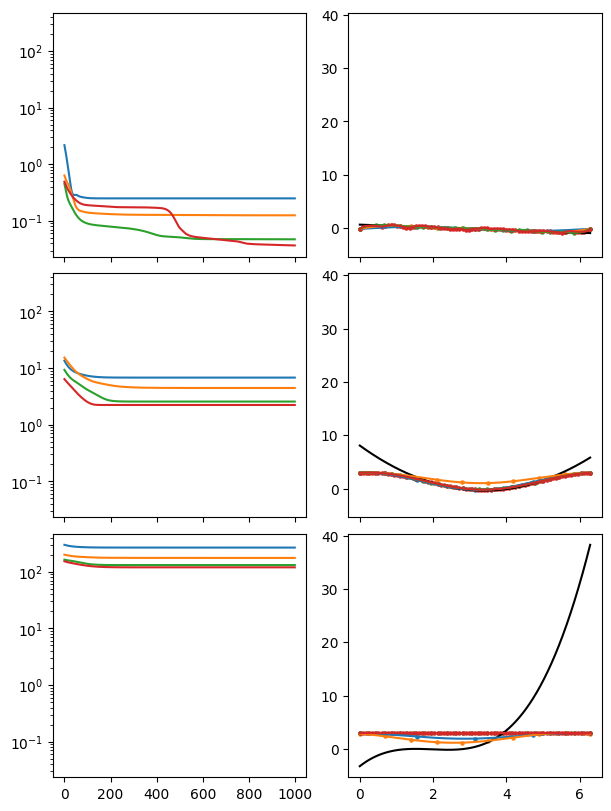

In [30]:
plt.style.use('default') # otherwise we get dark mode
fig, axes = plt.subplots(n_target_instances, 2, sharex='col', sharey='col', figsize=(6, 8), layout='constrained')

# mse training loss and rmse test loss
final_loss_values = np.zeros(shape=(2, n_target_instances*len(model_dict)))

iteration_order = []

xs = np.linspace(0, 2*np.pi, 1000)
for idx, target in enumerate(targets):
    label = "Target" if idx == 0 else ""
    axes[idx][1].plot(xs, target(xs), color='black', label=label)

for model_idx, (model_name, model) in enumerate(model_dict.items()):
    if model_idx > 0: print()
    print(f"Fitting model {model_name} ({model_idx + 1}/{len(model_dict)})")
    iteration_order.append(model_name)

    model_function = model["function"]
    circuit = qml.QNode(model_function, device)
    collocation_points = np.linspace(0, 2*np.pi, model["n_collocation_points"])
    color = color_sequences['tab10'][model_idx]

    for target_idx, target in enumerate(targets):
        print(f"Fitting to target {target_idx+1} out of {len(targets)}")
        cost = lambda theta: mse_loss(circuit, theta, collocation_points, target)

        optimiser = qml.AdamOptimizer(stepsize=stepsize)
        loss_values = np.zeros(n_steps)
        theta = rng.uniform(0, 2*np.pi, size=6*N_QUBITS, requires_grad=True)

        for step in tqdm(range(n_steps), total=n_steps):
            theta, loss_values[step] = optimiser.step_and_cost(cost, theta)

        rmse = np.sqrt(mse_loss(circuit, theta, xs, target))
        final_loss_values[0, n_target_instances*model_idx + target_idx] = loss_values[-1]
        final_loss_values[1, n_target_instances*model_idx + target_idx] = rmse

        label = model_name if target_idx == 0 else ""
        axes[target_idx][0].semilogy(range(n_steps), loss_values, color=color)
        axes[target_idx][1].plot(xs, circuit(xs, theta), color=color, label=label)
        axes[target_idx][1].scatter(collocation_points, circuit(collocation_points, theta), s=5, color=color)

#### Save the loss values, then finalise the plot and save the image

In [35]:
header = ",".join([f"{name}.{idx+1}" for name in iteration_order for idx in range(3)])
np.savetxt(file_name_table, final_loss_values, delimiter=",", fmt='%1.3e', header=header)

axes[0][0].set_title("Loss values per training step")
axes[0][1].set_title("Target versus model fits")
for row in axes:
    row[0].set_ylim(bottom=1e-6-5e-7)
    row[1].set_ylim(top=11)
    row[0].set_ylabel("MSE")
    row[1].set_ylabel("Output")
    row[0].grid(which='both')
    row[1].grid()
axes[-1][0].set_xlabel("Training step")
axes[-1][1].set_xlabel("Input")

fig.suptitle(f"Loss and fits to target {target_name}", fontsize=16)
fig.legend(loc='outside lower center')
fig.savefig(file_name_plot, dpi=300)